# Model 1

## Goals:
- write ANN model for training set using Ligand and Protein descriptors only (No Interaction descriptors yet).
- study the contribution of descriptors to the performance of Model-1. 

# 0. Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading Clean Dataset:

In [2]:
df = pd.read_csv('./1-Training_Database/V2-combined_bd_chmbl_unique.csv')
df.head(2)

,cid,Smiles,Standard Value,pIC50 Value
0,23647975.0,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.0,7.468521
1,5578.0,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.0,5.565112


In [3]:
# Convert the 'cid' column to integers
df['cid'] = df['cid'].astype(int)

In [4]:
df.shape

(875, 4)

In [5]:
# Drop row with df['Preprocessed Ligand SMILES'] =='CC1(C)CC=C(c2cc(C3(C#N)C[C@@]4(C)CC[C@](C)(C3)O4)ccc2NC(=O)c2nc(C#N)c[nH]2)CC1'
# It will further complicate the problem with 3D calculations.

smiles_to_drop = 'CC1(C)CC=C(c2cc(C3(C#N)C[C@@]4(C)CC[C@](C)(C3)O4)ccc2NC(=O)c2nc(C#N)c[nH]2)CC1'

# Drop rows where 'Preprocessed Ligand SMILES' is equal to the specified value
df = df[df['Smiles'] != smiles_to_drop]

df.shape

(875, 4)

In [6]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cid             875 non-null    int64  
 1   Smiles          875 non-null    object 
 2   Standard Value  875 non-null    float64
 3   pIC50 Value     875 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 27.5+ KB


In [7]:
df = df.dropna()

In [8]:
df.shape

(875, 4)

# 2a. Reading Ligand descriptors file: 1D, 2D, FP

In [9]:
df_lig = pd.read_csv('./2-Training_Descriptors_Calc/V2-TgDHFR-2d-descriptors_ligand.csv')
df_lig.head(2)

,Smiles,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,1,-0.9874,0.974959,55.7857,55.717446,12,12,49,27,...,0,0,0,0,0,0,0,0,0,0
1,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,0,-1.1990,1.437601,34.9926,43.448274,12,12,39,21,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df_lig.shape

(870, 2326)

# 2b. Reading Ligand descriptors file: 3D

In [18]:
df_lig_3d = pd.read_csv('./2-Training_Descriptors_Calc/V2-TgDHFR-3d-descriptors_ligand_GO_mmff94s.csv')
df_lig_3d.head(2)

,Name,TDB1u,TDB2u,TDB3u,TDB4u,TDB5u,TDB6u,TDB7u,TDB8u,TDB9u,...,P1s,P2s,E1s,E2s,E3s,Ts,As,Vs,Ks,Ds
0,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,1.254996,2.201673,3.103689,3.962396,4.719510,5.557423,6.310768,7.104393,7.897998,...,0.671270,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.29810,0.506905,1.383022
1,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,1.250840,2.176286,3.121375,3.917018,4.606636,5.472777,6.070544,6.997690,7.448239,...,0.681195,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.62338,0.521793,1.363389


In [19]:
# Add prefix to column names
df_lig_3d = df_lig_3d.add_prefix('3d-')

# Rename the column
df_lig_3d.rename(columns={'3d-Name': 'Smiles'}, inplace=True)

# Display the modified DataFrame
df_lig_3d.head()

,Smiles,3d-TDB1u,3d-TDB2u,3d-TDB3u,3d-TDB4u,3d-TDB5u,3d-TDB6u,3d-TDB7u,3d-TDB8u,3d-TDB9u,...,3d-P1s,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds
0,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,1.254996,2.201673,3.103689,3.962396,4.719510,5.557423,6.310768,7.104393,7.897998,...,0.671270,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.298100,0.506905,1.383022
1,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,1.250840,2.176286,3.121375,3.917018,4.606636,5.472777,6.070544,6.997690,7.448239,...,0.681195,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.623380,0.521793,1.363389
2,COc1ccc(OC)c(Cc2cnc3nc(N)nc(N)c3c2C)c1,1.260573,2.205699,3.164785,4.008417,4.709748,5.487354,6.298379,6.942693,7.685606,...,0.684686,0.233761,0.462430,0.432066,0.419386,17.602439,72.799899,161.593140,0.527029,1.313881
3,COc1ccc(OCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,1.261814,2.211434,3.104852,3.977466,4.734474,5.527540,6.341378,7.124420,7.820012,...,0.674622,0.267538,0.485090,0.455930,0.434351,22.911835,123.353904,271.825209,0.511934,1.375371
4,COc1ccc(OCCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,1.260856,2.208210,3.088044,3.951555,4.730086,5.517038,6.389618,7.196127,8.021782,...,0.805610,0.148660,0.490703,0.385535,0.402250,28.791849,135.454504,294.963130,0.708415,1.278488


In [13]:
df_lig_3d.shape

(869, 432)

# 3. Merging dataset with descriptors files (ligands and proteins).

In [14]:
# 1. Merge Dataset and file with ligand descriptor file: 1D,2D

merged_df=pd.DataFrame()

merged_df = df.merge(df_lig, on='Smiles', how='left')


In [15]:
merged_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 2329 columns):
 #     Column             Non-Null Count  Dtype  
---    ------             --------------  -----  
 0     cid                875 non-null    int64  
 1     Smiles             875 non-null    object 
 2     Standard Value     875 non-null    float64
 3     pIC50 Value        875 non-null    float64
 4     nAcid              875 non-null    int64  
 5     ALogP              875 non-null    float64
 6     ALogp2             875 non-null    float64
 7     AMR                875 non-null    float64
 8     apol               875 non-null    float64
 9     naAromAtom         875 non-null    int64  
 10    nAromBond          875 non-null    int64  
 11    nAtom              875 non-null    int64  
 12    nHeavyAtom         875 non-null    int64  
 13    nH                 875 non-null    int64  
 14    nB                 875 non-null    int64  
 15    nC                 875 non-null    i

In [16]:
merged_df.shape

(875, 2329)

In [20]:
# 2. Add Protein descriptors:
merged_df = merged_df.merge(df_lig_3d, on='Smiles', how='left')

In [21]:
merged_df.shape

(875, 2760)

In [22]:
merged_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 2760 columns):
 #     Column             Non-Null Count  Dtype  
---    ------             --------------  -----  
 0     cid                875 non-null    int64  
 1     Smiles             875 non-null    object 
 2     Standard Value     875 non-null    float64
 3     pIC50 Value        875 non-null    float64
 4     nAcid              875 non-null    int64  
 5     ALogP              875 non-null    float64
 6     ALogp2             875 non-null    float64
 7     AMR                875 non-null    float64
 8     apol               875 non-null    float64
 9     naAromAtom         875 non-null    int64  
 10    nAromBond          875 non-null    int64  
 11    nAtom              875 non-null    int64  
 12    nHeavyAtom         875 non-null    int64  
 13    nH                 875 non-null    int64  
 14    nB                 875 non-null    int64  
 15    nC                 875 non-null    i

In [46]:
# Assuming combined_bd_chmbl_unique is a DataFrame and you dropped NaN from 'pIC50 Value'
merged_df = merged_df.dropna(subset=['pIC50 Value'])

# Reindex the DataFrame to reset the index
merged_df.reset_index(drop=True, inplace=True)

merged_df.shape

(875, 2760)

# 4. Check dublicated SMILES: smiles same but cid different

In [23]:
merged_df['cid'].nunique()

875

In [24]:
merged_df['Smiles'].nunique()

870

In [25]:
# Identify duplicates in the 'Smiles' column
duplicates = merged_df[merged_df.duplicated('Smiles', keep=False)]

# Show the 'Smiles' and 'cid' columns for duplicates
duplicates_result = duplicates[['Smiles', 'cid']]

# Display the result
duplicates_result

,Smiles,cid
364,COc1ccc(OC)c(Sc2c(C)[nH]c3nc(N)[nH]c(=O)c23)c1,44568875
369,Nc1nc2[nH]c3cccc(Sc4cccc5ccccc45)c3c2c(=O)[nH]1,72725330
370,Nc1nc2[nH]c3cccc(Sc4ccccc4)c3c2c(=O)[nH]1,72725265
371,Nc1nc2[nH]c3cccc(Sc4ccc5ccccc5c4)c3c2c(=O)[nH]1,72725264
724,Cc1[nH]c2nc(N)[nH]c(=O)c2c1Sc1ccc(Cl)c(Cl)c1,10065888
815,Nc1nc2[nH]c3cccc(Sc4ccc5ccccc5c4)c3c2c(=O)[nH]1,136227773
816,COc1ccc(OC)c(Sc2c(C)[nH]c3nc(N)[nH]c(=O)c23)c1,135960753
817,Nc1nc2[nH]c3cccc(Sc4cccc5ccccc45)c3c2c(=O)[nH]1,135566835
818,Nc1nc2[nH]c3cccc(Sc4ccccc4)c3c2c(=O)[nH]1,135566834
820,Cc1[nH]c2nc(N)[nH]c(=O)c2c1Sc1ccc(Cl)c(Cl)c1,135543610


- Some compounds has dublicates: these dublicates has status 'not-live'.
- They will be dropped

In [27]:
status_not_live = [72725330, 44568875, 72725265, 72725264, 10065888]

# Remove rows from merged_df where 'cid' is in status_not_live list
merged_df_final = merged_df[~merged_df['cid'].isin(status_not_live)]

# Display the final data frame
merged_df_final.shape

(870, 2760)

In [28]:
merged_df_final = merged_df.copy()

merged_df = merged_df.reset_index(drop=True)

# 5. Quantile Transformation (QT) of pIC50

## 5.1. QT transformation

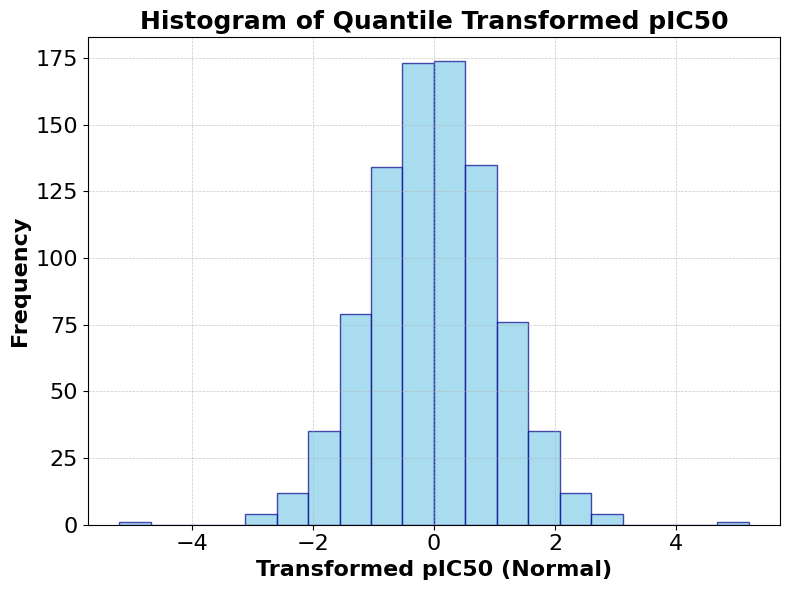

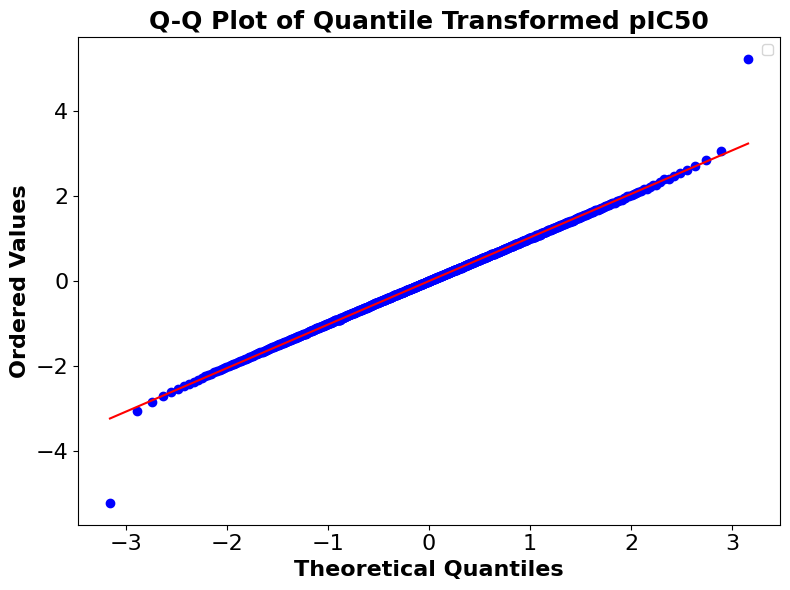

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from scipy import stats

# Assuming combined_bd_chmbl_unique is your DataFrame and it has a column 'pIC50 Value'
# df = pd.read_csv('your_data.csv')  # Uncomment and modify this line to read your actual data

# Extract the 'pIC50 Value' column
c_data = np.array(merged_df['pIC50 Value']).reshape(-1, 1)

# Apply Quantile Transformation
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
c_data_transformed = quantile_transformer.fit_transform(c_data).flatten()

# Add the transformed data to the DataFrame
merged_df['QT-pIC50 Value'] = c_data_transformed

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(c_data_transformed, bins=20, color='skyblue', edgecolor='darkblue', alpha=0.7)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Histogram of Quantile Transformed pIC50', fontsize=18, weight='bold')
plt.xlabel('Transformed pIC50 (Normal)', fontsize=16, weight='bold')
plt.ylabel('Frequency', fontsize=16, weight='bold')

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the plot
plt.show()

# Q-Q plot of transformed data with red normality line
plt.figure(figsize=(8, 6))
res = stats.probplot(c_data_transformed, dist="norm", plot=plt)

# Add title and legend
plt.title('Q-Q Plot of Quantile Transformed pIC50', fontsize=18, weight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=16, weight='bold')
plt.ylabel('Ordered Values', fontsize=16, weight='bold')
plt.legend()

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the Q-Q plot
plt.show()


In [32]:
shapiro_stat, shapiro_p_value = stats.shapiro(merged_df['QT-pIC50 Value'])

print(f"Shapiro-Wilk test statistic: {shapiro_stat}")
print(f"Shapiro-Wilk test p-value: {shapiro_p_value}")

Shapiro-Wilk test statistic: 0.9932653547977165
Shapiro-Wilk test p-value: 0.0005518404340312449


## 5.2. Z-test to filter outliers

In [33]:
# Outliers filtering:

import numpy as np
import pandas as pd

print(f"Number of rows before dropping outliers: {merged_df.shape[0]}")

# Assuming merged_df is your DataFrame and it contains the 'log_IC50' column
log_target = merged_df['QT-pIC50 Value']

# Calculate Z-scores
z_scores = np.abs((log_target - log_target.mean()) / log_target.std())

# Identify outliers based on Z-score
outliers_z = z_scores > 3

# Drop outliers from the DataFrame
merged_df = merged_df[~outliers_z]

# number of rows before and after dropping outliers
print(f"Number of rows after dropping outliers: {merged_df.shape[0]}")

Number of rows before dropping outliers: 875
Number of rows after dropping outliers: 873


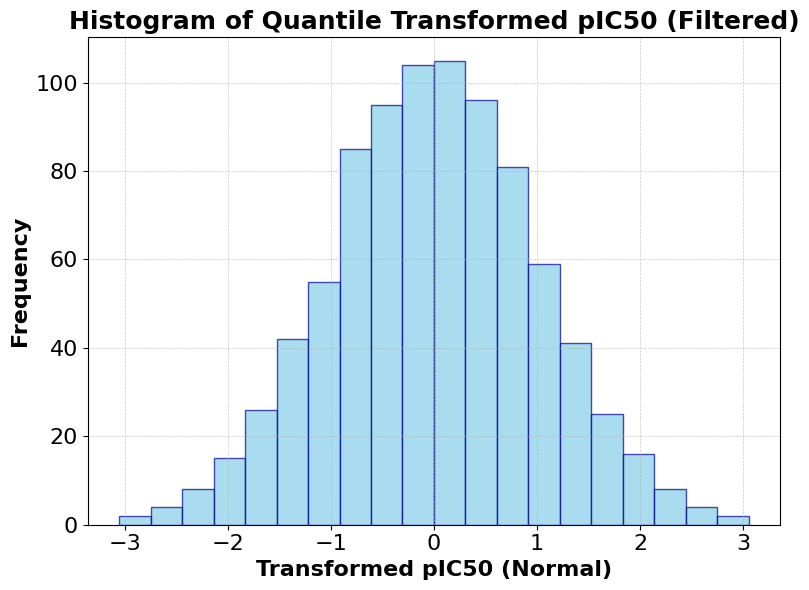

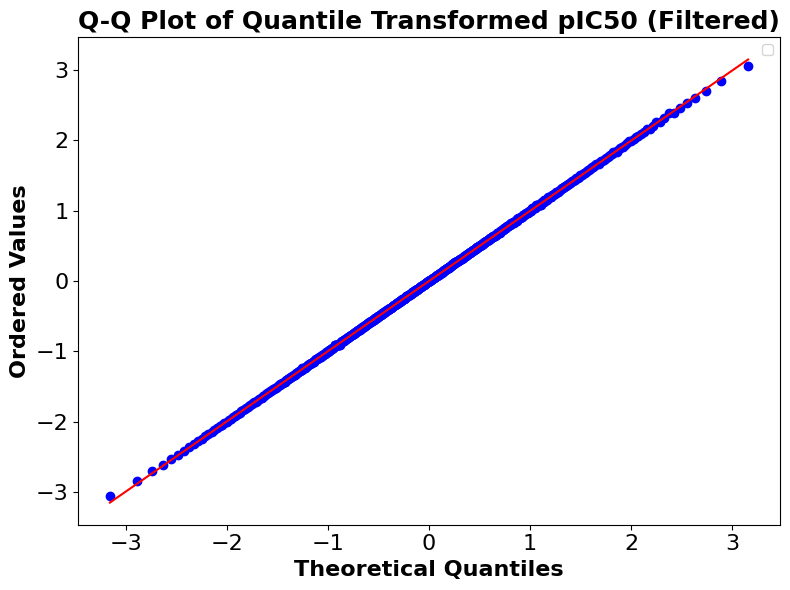

In [34]:
#Histogram and QQ-plot after QT and filtering og outliers

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
from scipy import stats

# Sample data for log_target, replace this with your actual data
c_data_transformed = merged_df['QT-pIC50 Value']

# Create the histogram
plt.figure(figsize=(8, 6))
plt.hist(c_data_transformed, bins=20, color='skyblue', edgecolor='darkblue', alpha=0.7)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Histogram of Quantile Transformed pIC50 (Filtered)', fontsize=18, weight='bold')
plt.xlabel('Transformed pIC50 (Normal)', fontsize=16, weight='bold')
plt.ylabel('Frequency', fontsize=16, weight='bold')

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the plot
plt.show()

# Q-Q plot of transformed data with red normality line
plt.figure(figsize=(8, 6))
res = stats.probplot(c_data_transformed, dist="norm", plot=plt)

# Add title and legend
plt.title('Q-Q Plot of Quantile Transformed pIC50 (Filtered)', fontsize=18, weight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=16, weight='bold')
plt.ylabel('Ordered Values', fontsize=16, weight='bold')
plt.legend()

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

# Display the Q-Q plot
plt.show()

In [35]:
shapiro_stat, shapiro_p_value = stats.shapiro(merged_df['QT-pIC50 Value'])

print(f"Shapiro-Wilk test statistic: {shapiro_stat}")
print(f"Shapiro-Wilk test p-value: {shapiro_p_value}")


Shapiro-Wilk test statistic: 0.9996805234764119
Shapiro-Wilk test p-value: 0.9999892912127311


In [36]:
merged_df.head()

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,23647975,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.000,7.468521,1,-0.9874,0.974959,55.7857,55.717446,12,...,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.298100,0.506905,1.383022,0.624900
1,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.000,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.623380,0.521793,1.363389,-0.538272
2,54369,COc1ccc(OC)c(Cc2cnc3nc(N)nc(N)c3c2C)c1,14.224,7.846978,0,-0.5052,0.255227,33.1789,49.693067,16,...,0.233761,0.462430,0.432066,0.419386,17.602439,72.799899,161.593140,0.527029,1.313881,1.108295
3,6481073,COc1ccc(OCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,1.900,8.721246,1,-1.0889,1.185703,46.8745,59.244239,16,...,0.267538,0.485090,0.455930,0.434351,22.911835,123.353904,271.825209,0.511934,1.375371,2.464251
4,6481074,COc1ccc(OCCCCC(O)=O)cc1Cc1cnc2nc(N)nc(N)c2c1C,2.300,8.638272,1,-1.3769,1.895854,49.7861,62.337825,16,...,0.148660,0.490703,0.385535,0.402250,28.791849,135.454504,294.963130,0.708415,1.278488,2.256690


## 5.3. How to invers QT transformation: Example

In [37]:
# Reshape the transformed data back to the original shape (2D array)
c_data_transformed_reshaped = merged_df['QT-pIC50 Value'].values.reshape(-1, 1)

# Inverse the transformation to get back to the original scale
c_data_inverse = quantile_transformer.inverse_transform(c_data_transformed_reshaped)

# Optionally, add the inversed data back to your DataFrame
merged_df['Inverse_QT-pIC50 Value'] = c_data_inverse.flatten()

# Print or check the inverse transformed values
print(merged_df[['QT-pIC50 Value', 'Inverse_QT-pIC50 Value','pIC50 Value']].head())

   QT-pIC50 Value  Inverse_QT-pIC50 Value  pIC50 Value
0        0.624900                7.468521     7.468521
1       -0.538272                5.565112     5.565112
2        1.108295                7.846978     7.846978
3        2.464251                8.721246     8.721246
4        2.256690                8.638272     8.638272


In [38]:
merged_df = merged_df.drop(columns='Inverse_QT-pIC50 Value')

In [39]:
merged_df.to_csv('V2-merged_df_noOutliers.csv',index=False)

# 6. Target = pIC50

## 6.1. Splitting Data

In [40]:
# Reset Indexes:
merged_df = merged_df.reset_index(drop=True)

In [41]:
# FOR MODEL

X = merged_df.drop(columns = ['Standard Value','pIC50 Value','Smiles','QT-pIC50 Value','cid'])
y = merged_df['pIC50 Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

## 6.2. Missing Data Imputation

In [42]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)


## 6.3. Removing Constants and Dublicated

In [43]:
%%time

# Drop constant
drop_const = DropConstantFeatures(tol=0.999)

drop_const.fit(X_train)
X_train = drop_const.transform(X_train)
X_test = drop_const.transform(X_test)

print(X_train.shape)

# Drop duplicates
drop_dup = DropDuplicateFeatures()

drop_dup.fit(X_train)
X_train = drop_dup.transform(X_train)
X_test = drop_dup.transform(X_test)

print(X_train.shape)

(742, 2121)
(742, 1858)
CPU times: user 920 ms, sys: 7.5 ms, total: 928 ms
Wall time: 933 ms


## 6.4. Outliers

In [44]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.72 µs


## 6.5. YeoJohnsonTransformer:

In [45]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

#Randomly sample 3736 rows from df_t25
yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train)

X_train = yeo_trans.transform(X_train)
X_test = yeo_trans.transform(X_test)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.25 µs


## 6.6. Scaling:

In [46]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train)

# Scale the training data
X_train_eda = scaler.transform(X_train)
X_test_eda = scaler.transform(X_test)

# Convert the numpy arrays back to DataFrames and assign column names
X_train = pd.DataFrame(X_train_eda, columns=X_train.columns)
X_test = pd.DataFrame(X_test_eda, columns=X_test.columns)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs


## 6.7. Multiple ANN Model (Average of 5 runs)

In [56]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize variables to store results
y_preds = []
maes = []
r2_scores = []

# Run the model 5 times
for i in range(5):
    print(f"Running model {i + 1}")
    # Define the neural network model
    model_1 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        #Dense(512, activation='relu'),
        #BatchNormalization(),
        #Dropout(0.4),
        #Dense(128, activation='relu'),
        #BatchNormalization(),
        #Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.0007)
    model_1.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )

    # Apply learning rate reduction on plateau
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=0.000001)

    # Define the EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    # Train the model
    history_improved = model_1.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=200,  # Reduced to 10 epochs for quicker testing
        validation_data=(X_test, y_test),
        shuffle=True,
        verbose=0,
        callbacks=[reduce_lr, early_stopping]
    )

    # Predict on the test set
    y_pred = model_1.predict(X_test)
    y_preds.append(y_pred.flatten())

    # Calculate MAE and R^2
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append MAE and R^2 to lists
    maes.append(mae)
    r2_scores.append(r2)

    # Delete the model to free up memory before the next iteration
    del model_1

# Convert y_preds list to a DataFrame
y_preds_df = pd.DataFrame(y_preds).T
y_preds_df.columns = [f'y_pred_run_{i+1}' for i in range(5)]
y_preds_df.index = y_test.index  # Use the same index as y_test

# Calculate the average y_pred across all runs
y_preds_df['average_y_pred'] = y_preds_df.mean(axis=1)

# Add y_test to the DataFrame
y_preds_df['y_test'] = y_test

# Calculate MAE and R^2 for the average predictions
average_mae = mean_absolute_error(y_test, y_preds_df['average_y_pred'])
average_r2 = r2_score(y_test, y_preds_df['average_y_pred'])

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(5)] + ['Average'],
    'R2': r2_scores + [average_r2],
    'MAE': maes + [average_mae]
})

Running model 1
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Running model 2
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 3
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 4
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


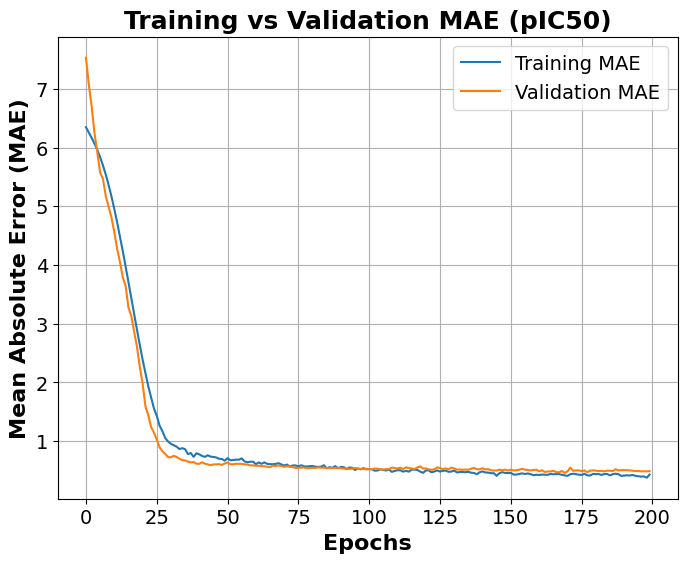

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plotting MAE for training and validation (test) data
plt.plot(history_improved.history['mae'], label='Training MAE')
plt.plot(history_improved.history['val_mae'], label='Validation MAE')

# Adding title, labels, grid, and legend
plt.title('Training vs Validation MAE (pIC50)', fontsize=18, weight='bold')
plt.xlabel('Epochs', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Error (MAE)', fontsize=16, weight='bold')
plt.grid(True)
plt.legend(fontsize=14)

# Adjusting tick parameters
plt.tick_params(axis='both', which='major', labelsize=14)

# Display the plot
plt.show()

In [58]:
y_preds_df.head(10)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test
795,7.481468,7.801305,7.753548,7.593038,7.928951,7.711662,7.886057
319,5.285185,5.330835,5.167536,5.297995,5.461864,5.308683,5.769551
382,7.237749,7.538920,7.103492,7.485972,7.379383,7.349103,7.244125
737,5.105734,5.504673,5.491929,5.502547,5.387544,5.398486,5.387216
422,6.672800,6.334927,6.609259,6.610988,6.591924,6.563979,6.008774
327,6.160149,5.863636,5.526458,6.617085,6.358650,6.105196,6.853872
804,7.274435,7.460550,7.256124,7.144553,7.341845,7.295501,7.000000
136,7.858526,7.908301,8.032992,8.065669,8.061763,7.985451,8.698970
670,4.620396,4.676025,4.714501,4.882316,4.974067,4.773461,4.812479
777,4.392264,4.663742,4.869735,4.516343,4.494044,4.587225,4.158641


In [59]:
summary_df

,Run,R2,MAE
0,Run 1,0.701898,0.493300
1,Run 2,0.727896,0.475269
2,Run 3,0.694657,0.536080
3,Run 4,0.746297,0.471983
4,Run 5,0.732561,0.461682
5,Average,0.746263,0.462149


## 6.8. Saveing Output: Relative Error (%)

In [60]:
y_preds_df['Relative_Error_%'] = (y_preds_df['average_y_pred'] - y_preds_df['y_test'])/y_preds_df['y_test'] * 100
y_preds_df.head()

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
795,7.481468,7.801305,7.753548,7.593038,7.928951,7.711662,7.886057,-2.211427
319,5.285185,5.330835,5.167536,5.297995,5.461864,5.308683,5.769551,-7.987938
382,7.237749,7.538920,7.103492,7.485972,7.379383,7.349103,7.244125,1.449144
737,5.105734,5.504673,5.491929,5.502547,5.387544,5.398486,5.387216,0.209190
422,6.672800,6.334927,6.609259,6.610988,6.591924,6.563979,6.008774,9.239909


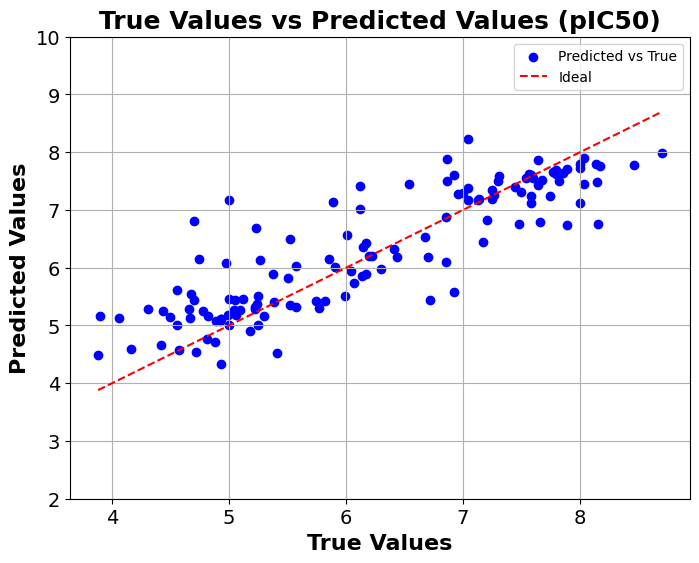

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_preds_df['y_test'], y_preds_df['average_y_pred'], color='blue', label='Predicted vs True')

# Adding the red line representing the ideal case (y = x)
min_val = min(y_preds_df['y_test'].min(), y_preds_df['average_y_pred'].min())
max_val = max(y_preds_df['y_test'].max(), y_preds_df['average_y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')

# Limiting the y-axis to the range [4, 9]
plt.ylim(2, 10)

# Adding title, labels, grid, and legend
plt.title('True Values vs Predicted Values (pIC50)', fontsize=18, weight='bold')
plt.xlabel('True Values', fontsize=16, weight='bold')
plt.ylabel('Predicted Values', fontsize=16, weight='bold')
plt.grid(True)
plt.legend()

plt.tick_params(axis='both', which='major', labelsize=14)

plt.show()

In [62]:
# Save the updated DataFrame to a CSV file
y_preds_df.to_csv('V2-output_model_2d_3d_fp_all_avrg_pic50.csv', index=False)

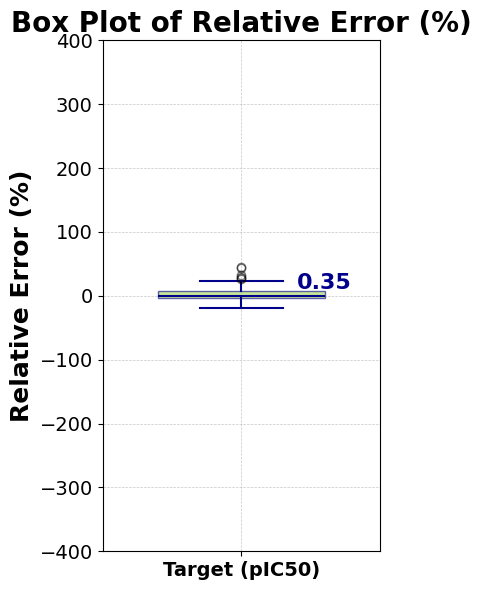

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

log_target_test = y_preds_df['Relative_Error_%']

plt.figure(figsize=(4, 6))

# Create the box plot with adjusted box width and frame thickness
box = plt.boxplot([log_target_test], 
                  vert=True, patch_artist=True, widths=0.6,  # Increase the box width
                  boxprops=dict(facecolor='none', color='darkblue', linewidth=1),  # Thinner box frame
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the color of the box
colors = ['#a6d854']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=20, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=18, weight='bold')
plt.xticks([1], ['Target (pIC50)'], fontsize=18, weight='bold')

# Adding median value as text, positioned above the box plot
median = box['medians'][0].get_ydata()[0]
plt.text(1.2, median + 20, f'{median:.2f}', horizontalalignment='left', color='darkblue', weight='semibold', va='center', fontsize=16)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(-400, 400)  # Set y-axis limit
plt.tight_layout()

# Display the plot
plt.show()

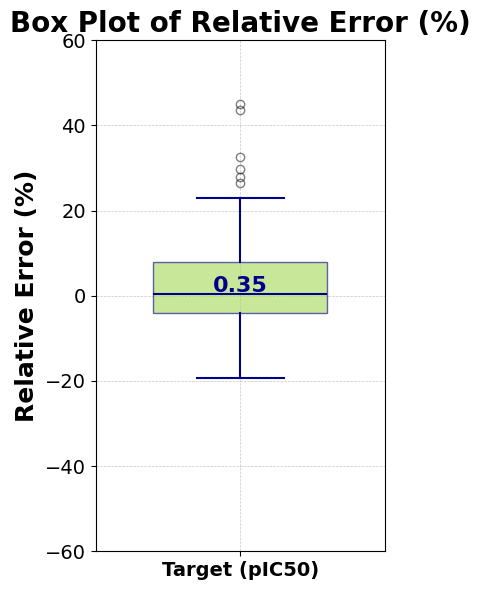

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

log_target_test = y_preds_df['Relative_Error_%']

plt.figure(figsize=(4, 6))

# Create the box plot with adjusted box width and frame thickness
box = plt.boxplot([log_target_test], 
                  vert=True, patch_artist=True, widths=0.6,  # Increase the box width
                  boxprops=dict(facecolor='none', color='darkblue', linewidth=1),  # Thinner box frame
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the color of the box
colors = ['#a6d854']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=20, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=18, weight='bold')
plt.xticks([1], ['Target (pIC50)'], fontsize=18, weight='bold')

# Adding median value as text, positioned above the box plot
median = box['medians'][0].get_ydata()[0]
plt.text(1, median + 2, f'{median:.2f}', horizontalalignment='center', color='darkblue', weight='semibold', va='center', fontsize=16)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(-60, 60)  # Set y-axis limit
plt.tight_layout()

# Display the plot
plt.show()


# 8. Target = QT-pIC50

## 8.1. Splitting Data

In [65]:
# Reset Indexes:
merged_df = merged_df.reset_index(drop=True)

In [66]:
# FOR MODEL

X = merged_df.drop(columns = ['Standard Value','pIC50 Value','Smiles','QT-pIC50 Value'])
y = merged_df['QT-pIC50 Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

## 8.2. Missing Data Imputation

In [67]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)


## 8.3. Removing Constants and Dublicated

In [68]:
%%time

# Drop constant
drop_const = DropConstantFeatures(tol=0.999)

drop_const.fit(X_train)
X_train = drop_const.transform(X_train)
X_test = drop_const.transform(X_test)

print(X_train.shape)

# Drop duplicates
drop_dup = DropDuplicateFeatures()

drop_dup.fit(X_train)
X_train = drop_dup.transform(X_train)
X_test = drop_dup.transform(X_test)

print(X_train.shape)

(742, 2122)
(742, 1859)
CPU times: user 853 ms, sys: 14.2 ms, total: 867 ms
Wall time: 870 ms


## 8.4. Outliers

In [69]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.58 µs


## 8.5. YeoJohnsonTransformer:

In [70]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

#Randomly sample 3736 rows from df_t25
yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train)

X_train = yeo_trans.transform(X_train)
X_test = yeo_trans.transform(X_test)

CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 14.1 µs


## 8.6. Scaling:

In [71]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train)

# Scale the training data
X_train_eda = scaler.transform(X_train)
X_test_eda = scaler.transform(X_test)

# Convert the numpy arrays back to DataFrames and assign column names
X_train = pd.DataFrame(X_train_eda, columns=X_train.columns)
X_test = pd.DataFrame(X_test_eda, columns=X_test.columns)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 9.54 µs


## 8.7. Multiple ANN Model (Average of 5 runs)

In [82]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize variables to store results
y_preds = []
maes = []
r2_scores = []

# Run the model 5 times
for i in range(5):
    print(f"Running model {i + 1}")
    # Define the neural network model
    model_1 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.0007)
    model_1.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )

    # Apply learning rate reduction on plateau
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=0.000001)

    # Define the EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    # Train the model
    history_improved = model_1.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=100,  # Reduced to 10 epochs for quicker testing
        validation_data=(X_test, y_test),
        shuffle=True,
        verbose=0,
        callbacks=[reduce_lr, early_stopping]
    )

    # Predict on the test set
    y_pred = model_1.predict(X_test)
    y_preds.append(y_pred.flatten())

    # Calculate MAE and R^2
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append MAE and R^2 to lists
    maes.append(mae)
    r2_scores.append(r2)

    # Delete the model to free up memory before the next iteration
    del model_1

# Convert y_preds list to a DataFrame
y_preds_df = pd.DataFrame(y_preds).T
y_preds_df.columns = [f'y_pred_run_{i+1}' for i in range(5)]
y_preds_df.index = y_test.index  # Use the same index as y_test

# Calculate the average y_pred across all runs
y_preds_df['average_y_pred'] = y_preds_df.mean(axis=1)

# Add y_test to the DataFrame
y_preds_df['y_test'] = y_test

# Calculate MAE and R^2 for the average predictions
average_mae = mean_absolute_error(y_test, y_preds_df['average_y_pred'])
average_r2 = r2_score(y_test, y_preds_df['average_y_pred'])

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(5)] + ['Average'],
    'R2': r2_scores + [average_r2],
    'MAE': maes + [average_mae]
})

Running model 1
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Running model 2
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 3
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 4
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Running model 5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


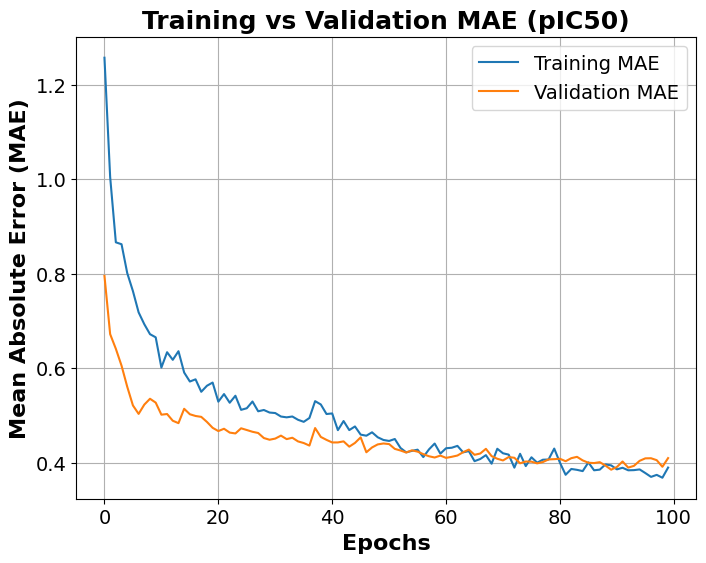

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plotting MAE for training and validation (test) data
plt.plot(history_improved.history['mae'], label='Training MAE')
plt.plot(history_improved.history['val_mae'], label='Validation MAE')

# Adding title, labels, grid, and legend
plt.title('Training vs Validation MAE (pIC50)', fontsize=18, weight='bold')
plt.xlabel('Epochs', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Error (MAE)', fontsize=16, weight='bold')
plt.grid(True)
plt.legend(fontsize=14)

# Adjusting tick parameters
plt.tick_params(axis='both', which='major', labelsize=14)

# Display the plot
plt.show()

In [84]:
y_preds_df.head(10)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test
795,0.969418,0.974799,0.854426,1.194450,0.958506,0.990320,1.154528
319,-0.488414,-0.569873,-0.706238,-0.548546,-0.672278,-0.597070,-0.392745
382,0.461579,0.536726,0.538056,0.786969,0.693194,0.603305,0.485950
737,-0.411573,-0.661553,-0.676143,-0.474303,-0.542319,-0.553178,-0.630138
422,-0.097589,-0.033196,0.260920,0.255882,-0.006665,0.075870,-0.197739
327,-0.179286,0.004524,0.015913,0.171459,-0.371741,-0.071826,0.264023
804,0.497348,0.702618,0.512809,0.576406,0.329657,0.523768,0.333005
136,1.326179,1.459011,1.550987,1.373156,1.384014,1.418669,2.383208
670,-1.188195,-1.182781,-1.084735,-1.369953,-1.308800,-1.226893,-1.127040
777,-1.396103,-1.376507,-1.304104,-1.452811,-1.419513,-1.389807,-1.867836


In [85]:
summary_df

,Run,R2,MAE
0,Run 1,0.663366,0.410917
1,Run 2,0.687745,0.387699
2,Run 3,0.691023,0.387079
3,Run 4,0.646960,0.419794
4,Run 5,0.693530,0.389254
5,Average,0.692339,0.384615


## 8.8. Saveing Output:

In [ ]:
y_preds_df_qq = y_preds_df

In [86]:
y_preds_df_qq['Relative_Error_%'] = (y_preds_df['average_y_pred'] - y_preds_df['y_test'])/y_preds_df['y_test'] * 100
y_preds_df_qq.head()

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
795,0.969418,0.974799,0.854426,1.194450,0.958506,0.990320,1.154528,-14.222981
319,-0.488414,-0.569873,-0.706238,-0.548546,-0.672278,-0.597070,-0.392745,52.024878
382,0.461579,0.536726,0.538056,0.786969,0.693194,0.603305,0.485950,24.149433
737,-0.411573,-0.661553,-0.676143,-0.474303,-0.542319,-0.553178,-0.630138,-12.213244
422,-0.097589,-0.033196,0.260920,0.255882,-0.006665,0.075870,-0.197739,-138.369019


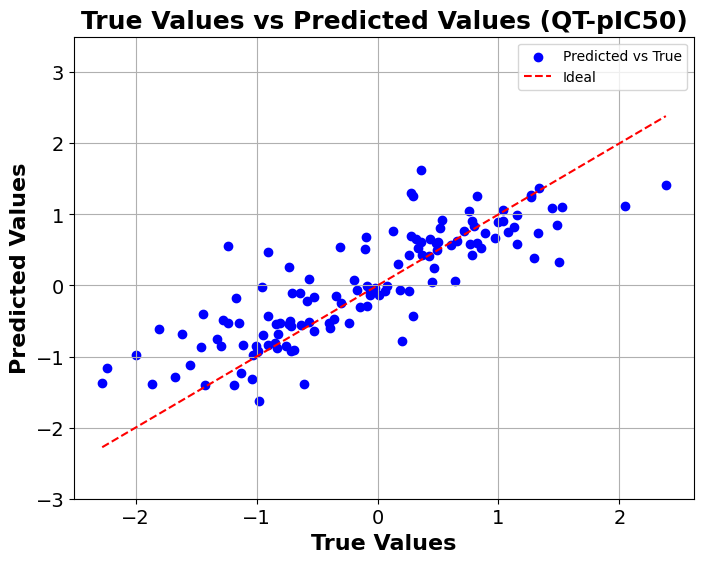

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_preds_df['y_test'], y_preds_df['average_y_pred'], color='blue', label='Predicted vs True')

# Adding the red line representing the ideal case (y = x)
min_val = min(y_preds_df['y_test'].min(), y_preds_df['average_y_pred'].min())
max_val = max(y_preds_df['y_test'].max(), y_preds_df['average_y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')

# Limiting the y-axis to the range [4, 9]
plt.ylim(-3, 3.5)

# Adding title, labels, grid, and legend
plt.title('True Values vs Predicted Values (QT-pIC50)', fontsize=18, weight='bold')
plt.xlabel('True Values', fontsize=16, weight='bold')
plt.ylabel('Predicted Values', fontsize=16, weight='bold')
plt.grid(True)
plt.legend()

plt.tick_params(axis='both', which='major', labelsize=14)

plt.show()


In [90]:
# Save the updated DataFrame to a CSV file
y_preds_df.to_csv('V2-output_model_2d_3d_fp_all_avrg_QTipc50.csv', index=False)

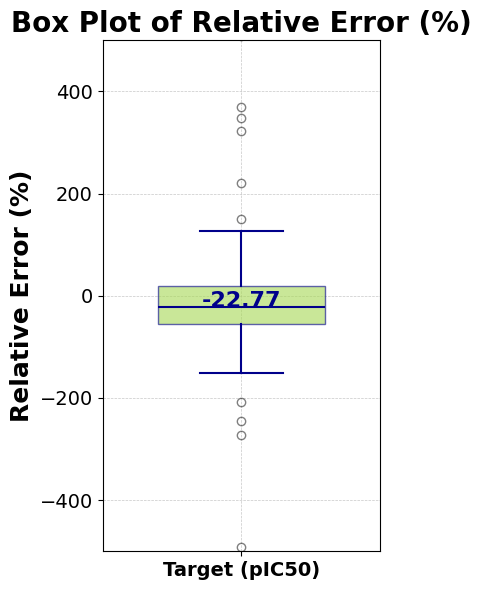

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

log_target_test = y_preds_df['Relative_Error_%']

plt.figure(figsize=(4, 6))

# Create the box plot with adjusted box width and frame thickness
box = plt.boxplot([log_target_test], 
                  vert=True, patch_artist=True, widths=0.6,  # Increase the box width
                  boxprops=dict(facecolor='none', color='darkblue', linewidth=1),  # Thinner box frame
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the color of the box
colors = ['#a6d854']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=20, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=18, weight='bold')
plt.xticks([1], ['Target (pIC50)'], fontsize=18, weight='bold')

# Adding median value as text, positioned above the box plot
median = box['medians'][0].get_ydata()[0]
plt.text(1, median + 12, f'{median:.2f}', horizontalalignment='center', color='darkblue', weight='semibold', va='center', fontsize=16)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(-500, 500)  # Set y-axis limit
plt.tight_layout()

# Display the plot
plt.show()
